##### Load DF with correct only 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path
import csv
import json

warnings.filterwarnings("ignore")

path = Path("results")
r_path = Path("results_correct_only")

df = pd.read_csv(path / "200_feature_attributions.csv", dtype={"ig_token": str})
df_ds = pd.read_csv(
    "dataset.txt", sep="\t", quoting=csv.QUOTE_NONE, dtype={"ig_token": str}
)
info = json.load(open("info.json", "r"))
df_ds = df_ds[df_ds["id"].isin(info["id"])]
df_ds["pred"] = (df_ds["probability"] >= 0.5).astype(int)
correct_ids = df_ds[df_ds["label"] == df_ds["pred"]]["id"]
df = df[df["id"].isin(correct_ids)]

NUM_TOP_FEATURES = 10

display(df.info())

df["ig_token"] = df["ig_token"].fillna("[EMPTY]")
print(df["id"].nunique())

<class 'pandas.core.frame.DataFrame'>
Index: 57195 entries, 0 to 80900
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            57195 non-null  int64  
 1   id                    57195 non-null  int64  
 2   dataset               57195 non-null  object 
 3   sv_value              57195 non-null  float64
 4   sv_token              57194 non-null  object 
 5   sv_base_value         57195 non-null  float64
 6   ig_value              57195 non-null  float64
 7   ig_token              57192 non-null  object 
 8   ig_base_value         57195 non-null  float64
 9   gpt_index_value       57191 non-null  float64
 10  gpt_index_word_value  57151 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 5.2+ MB


None

141


# Bar charts
Get the bar graphs for the top 15 most important positive and negative features

<class 'pandas.core.frame.DataFrame'>
Index: 57195 entries, 0 to 80900
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            57195 non-null  int64  
 1   id                    57195 non-null  int64  
 2   dataset               57195 non-null  object 
 3   sv_value              57195 non-null  float64
 4   sv_token              57194 non-null  object 
 5   sv_base_value         57195 non-null  float64
 6   ig_value              57195 non-null  float64
 7   ig_token              57192 non-null  object 
 8   ig_base_value         57195 non-null  float64
 9   gpt_index_value       57191 non-null  float64
 10  gpt_index_word_value  57151 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 5.2+ MB


None

141
N features: 57195
N unique features: 5341
0
5341
There are 5341 unique tokens that occurred 1+ times.
57195 tokens remain.
There are 816 unique tokens that occurred 10+ times.
45206 tokens remain.
There are 57 unique tokens that occurred 100+ times.
26613 tokens remain.


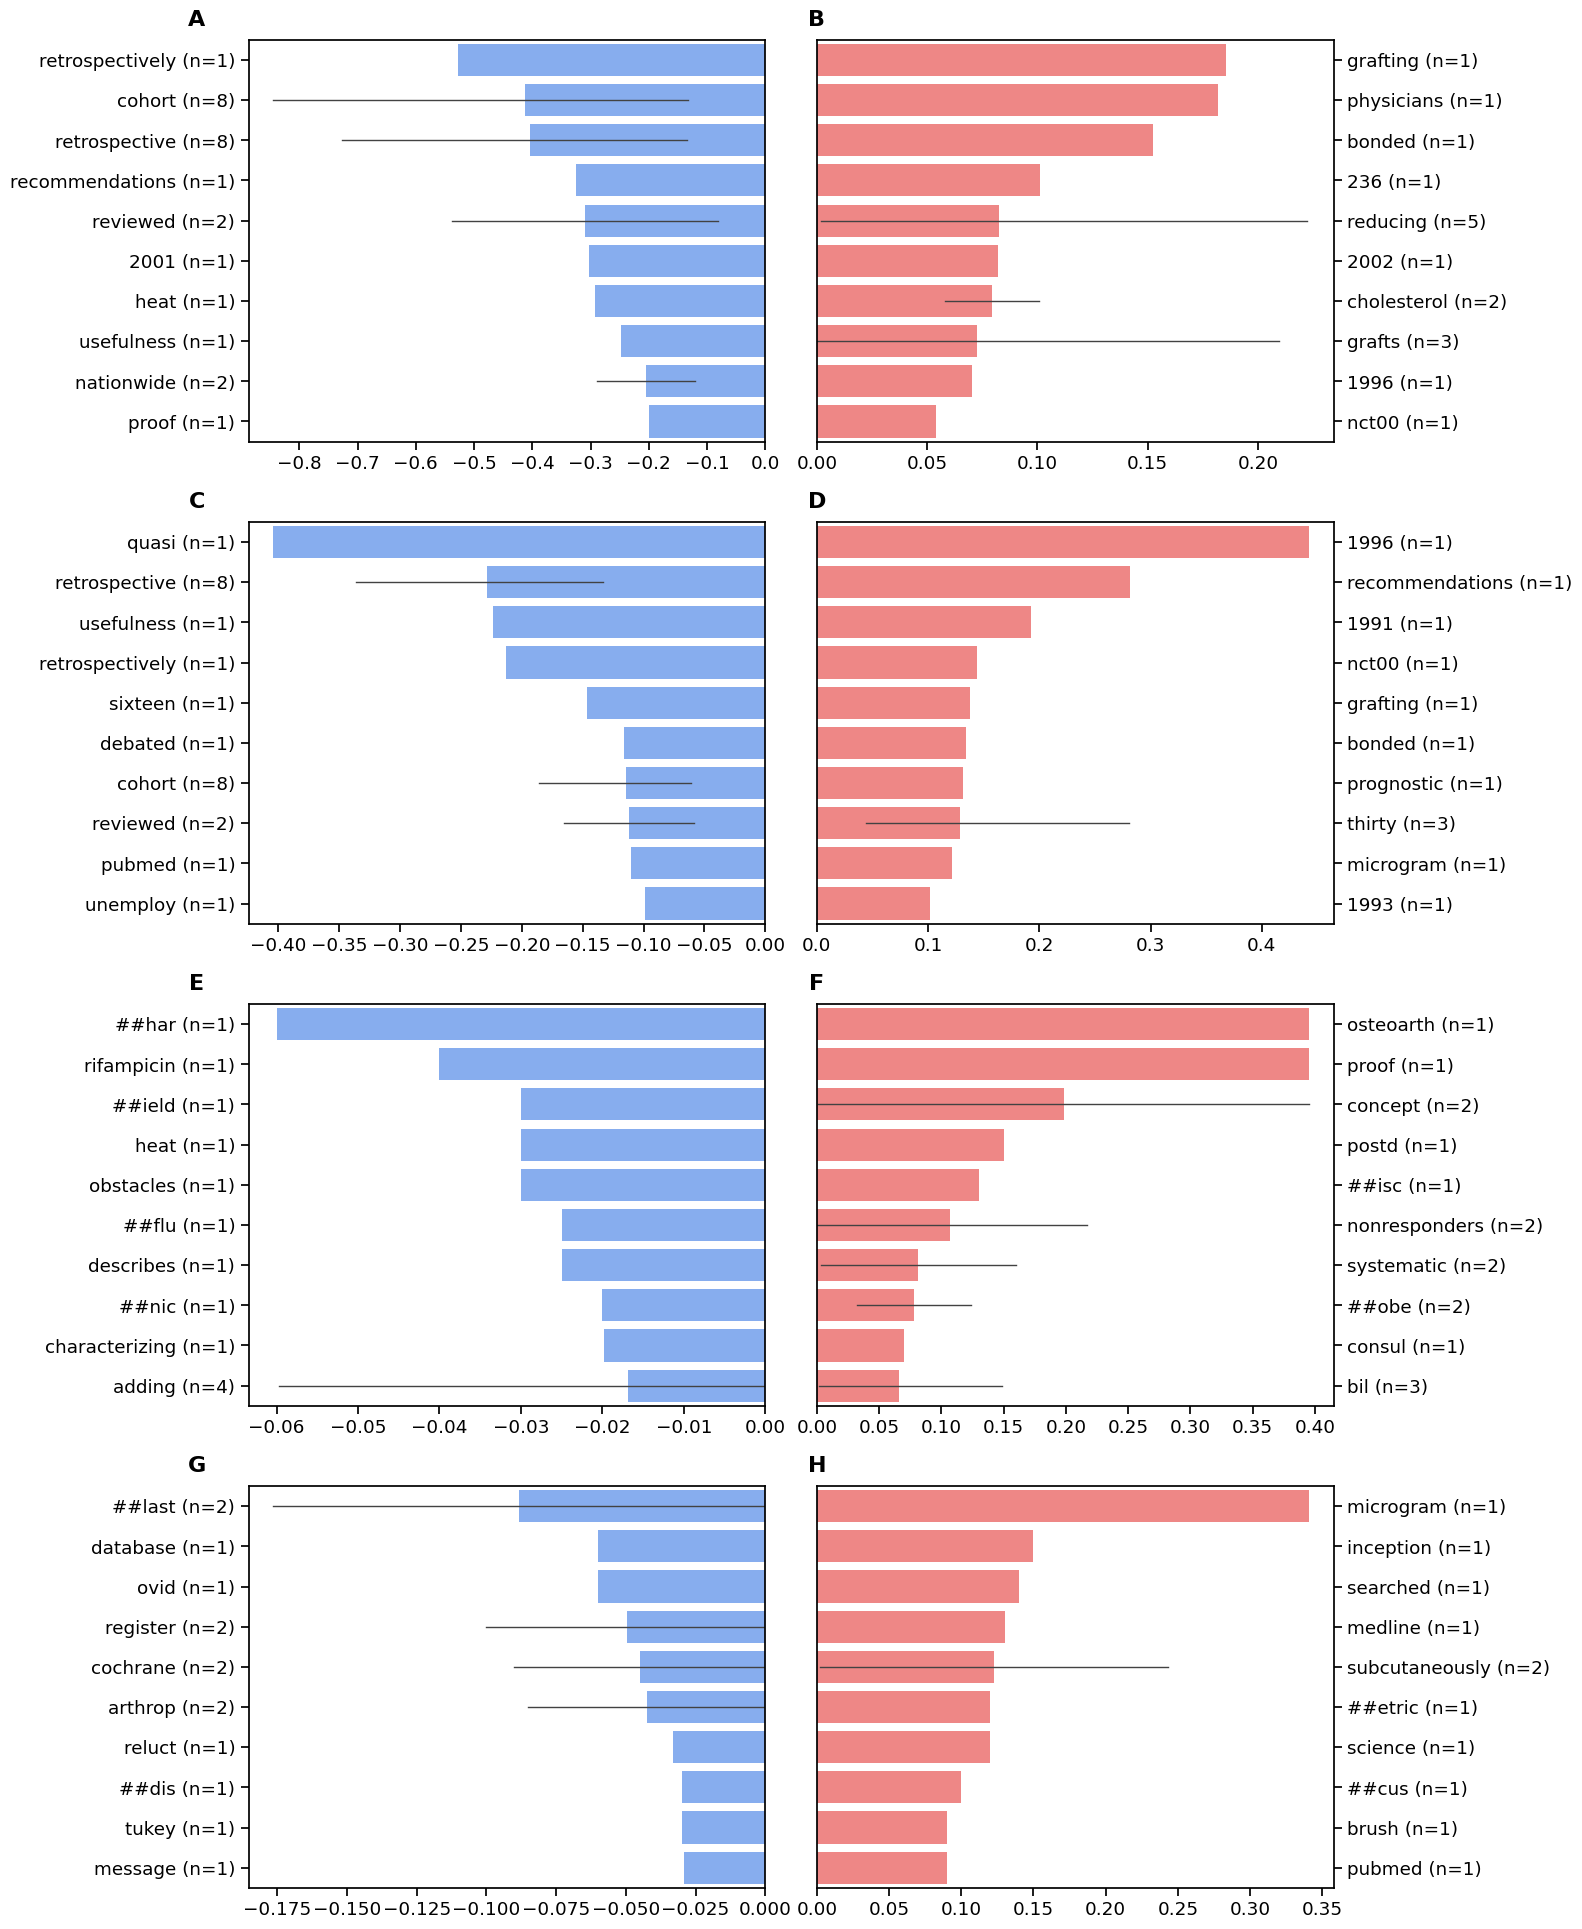

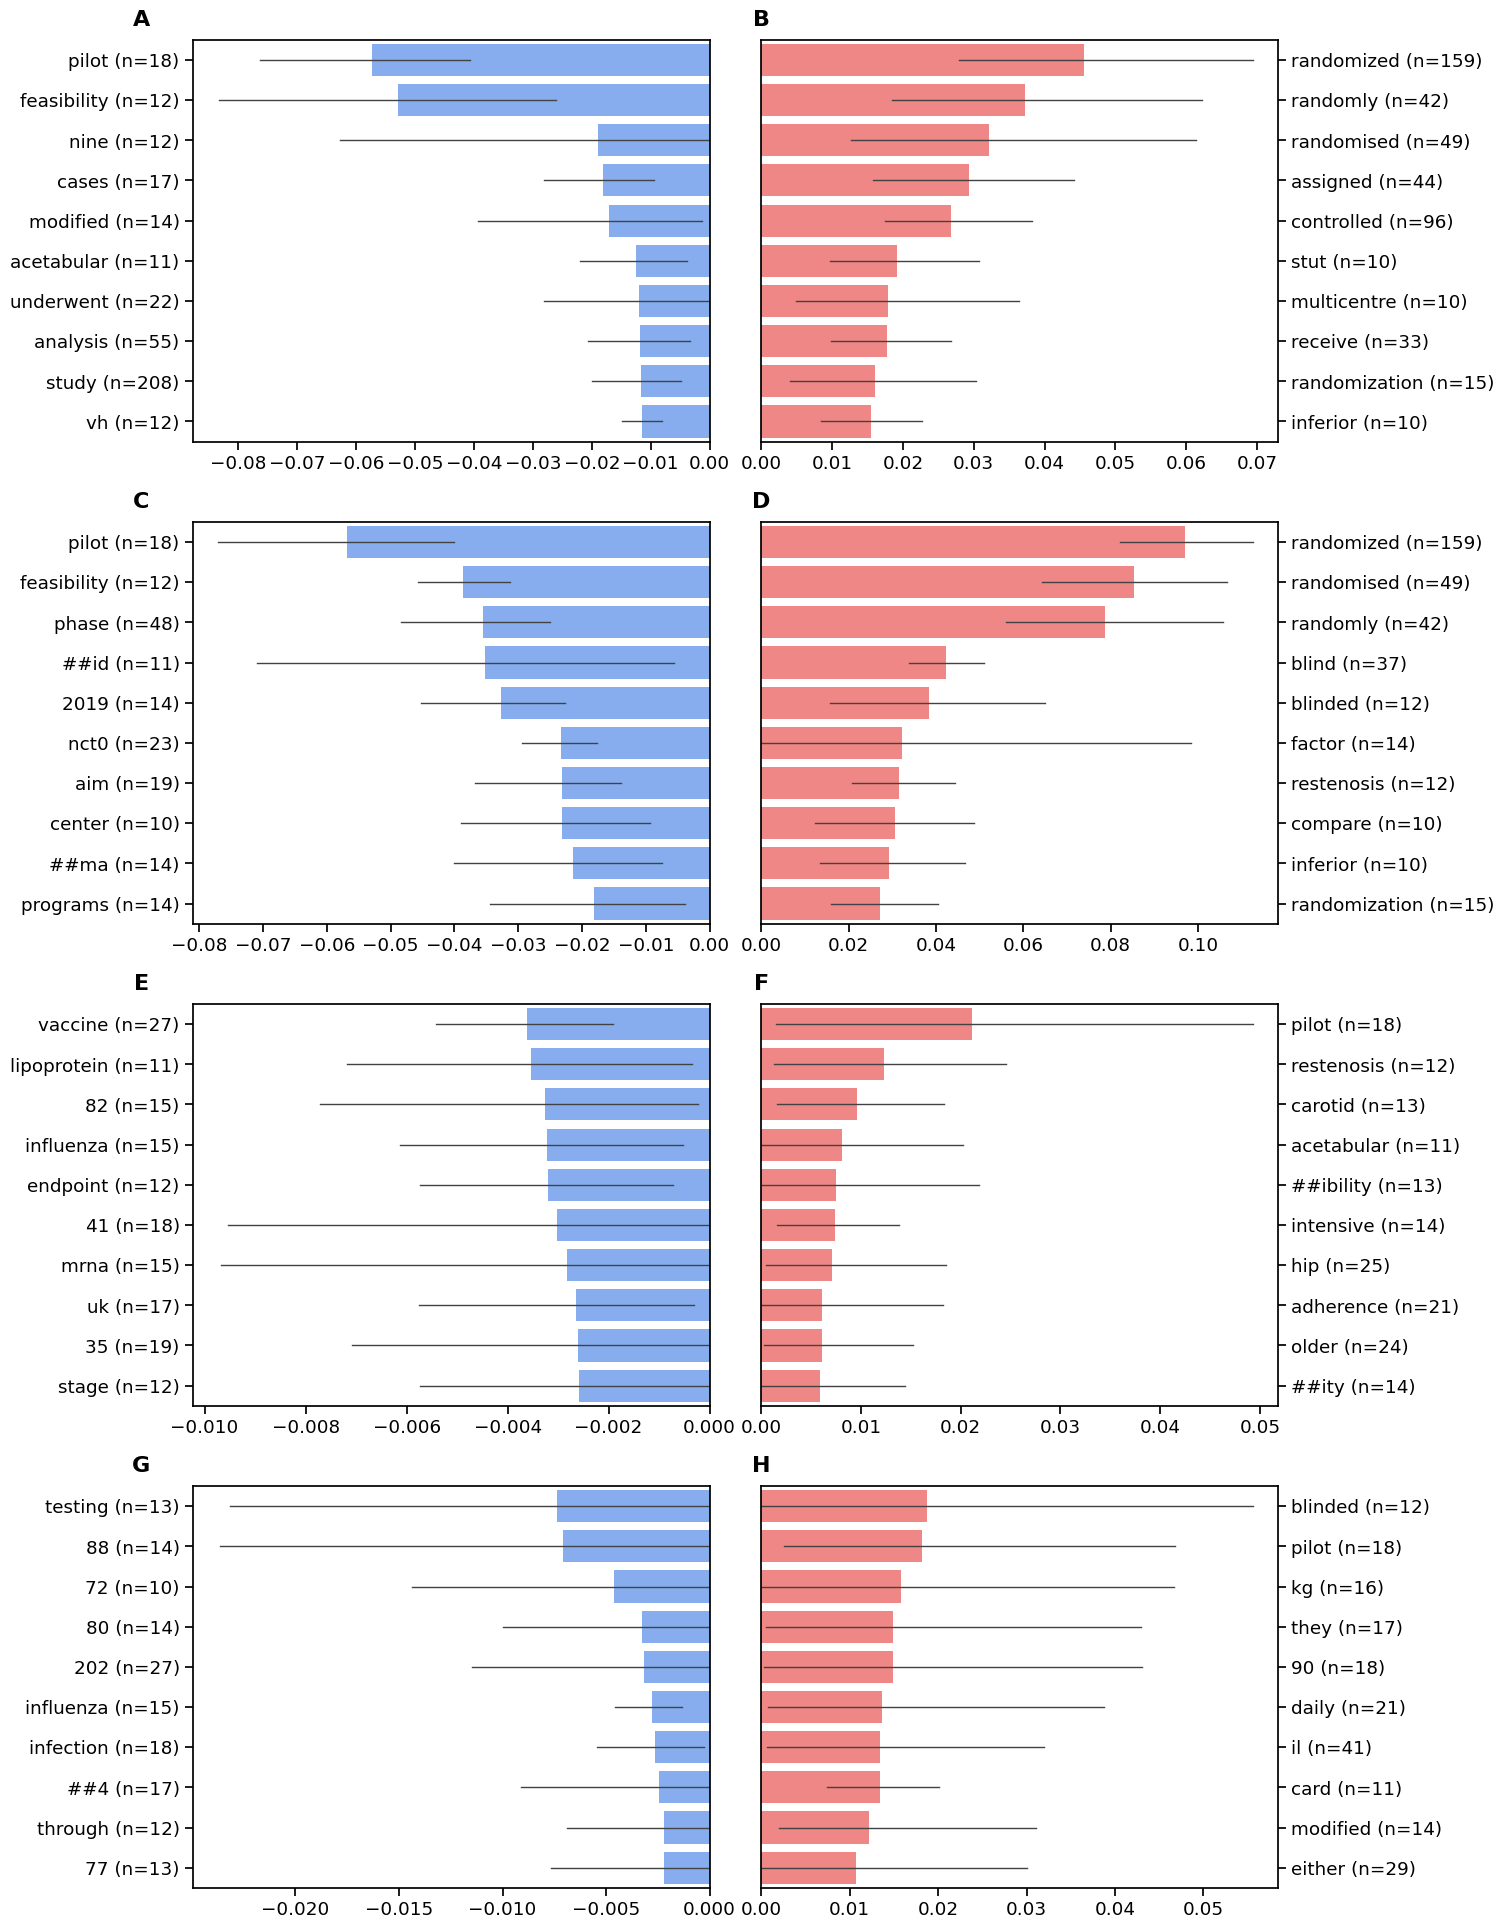

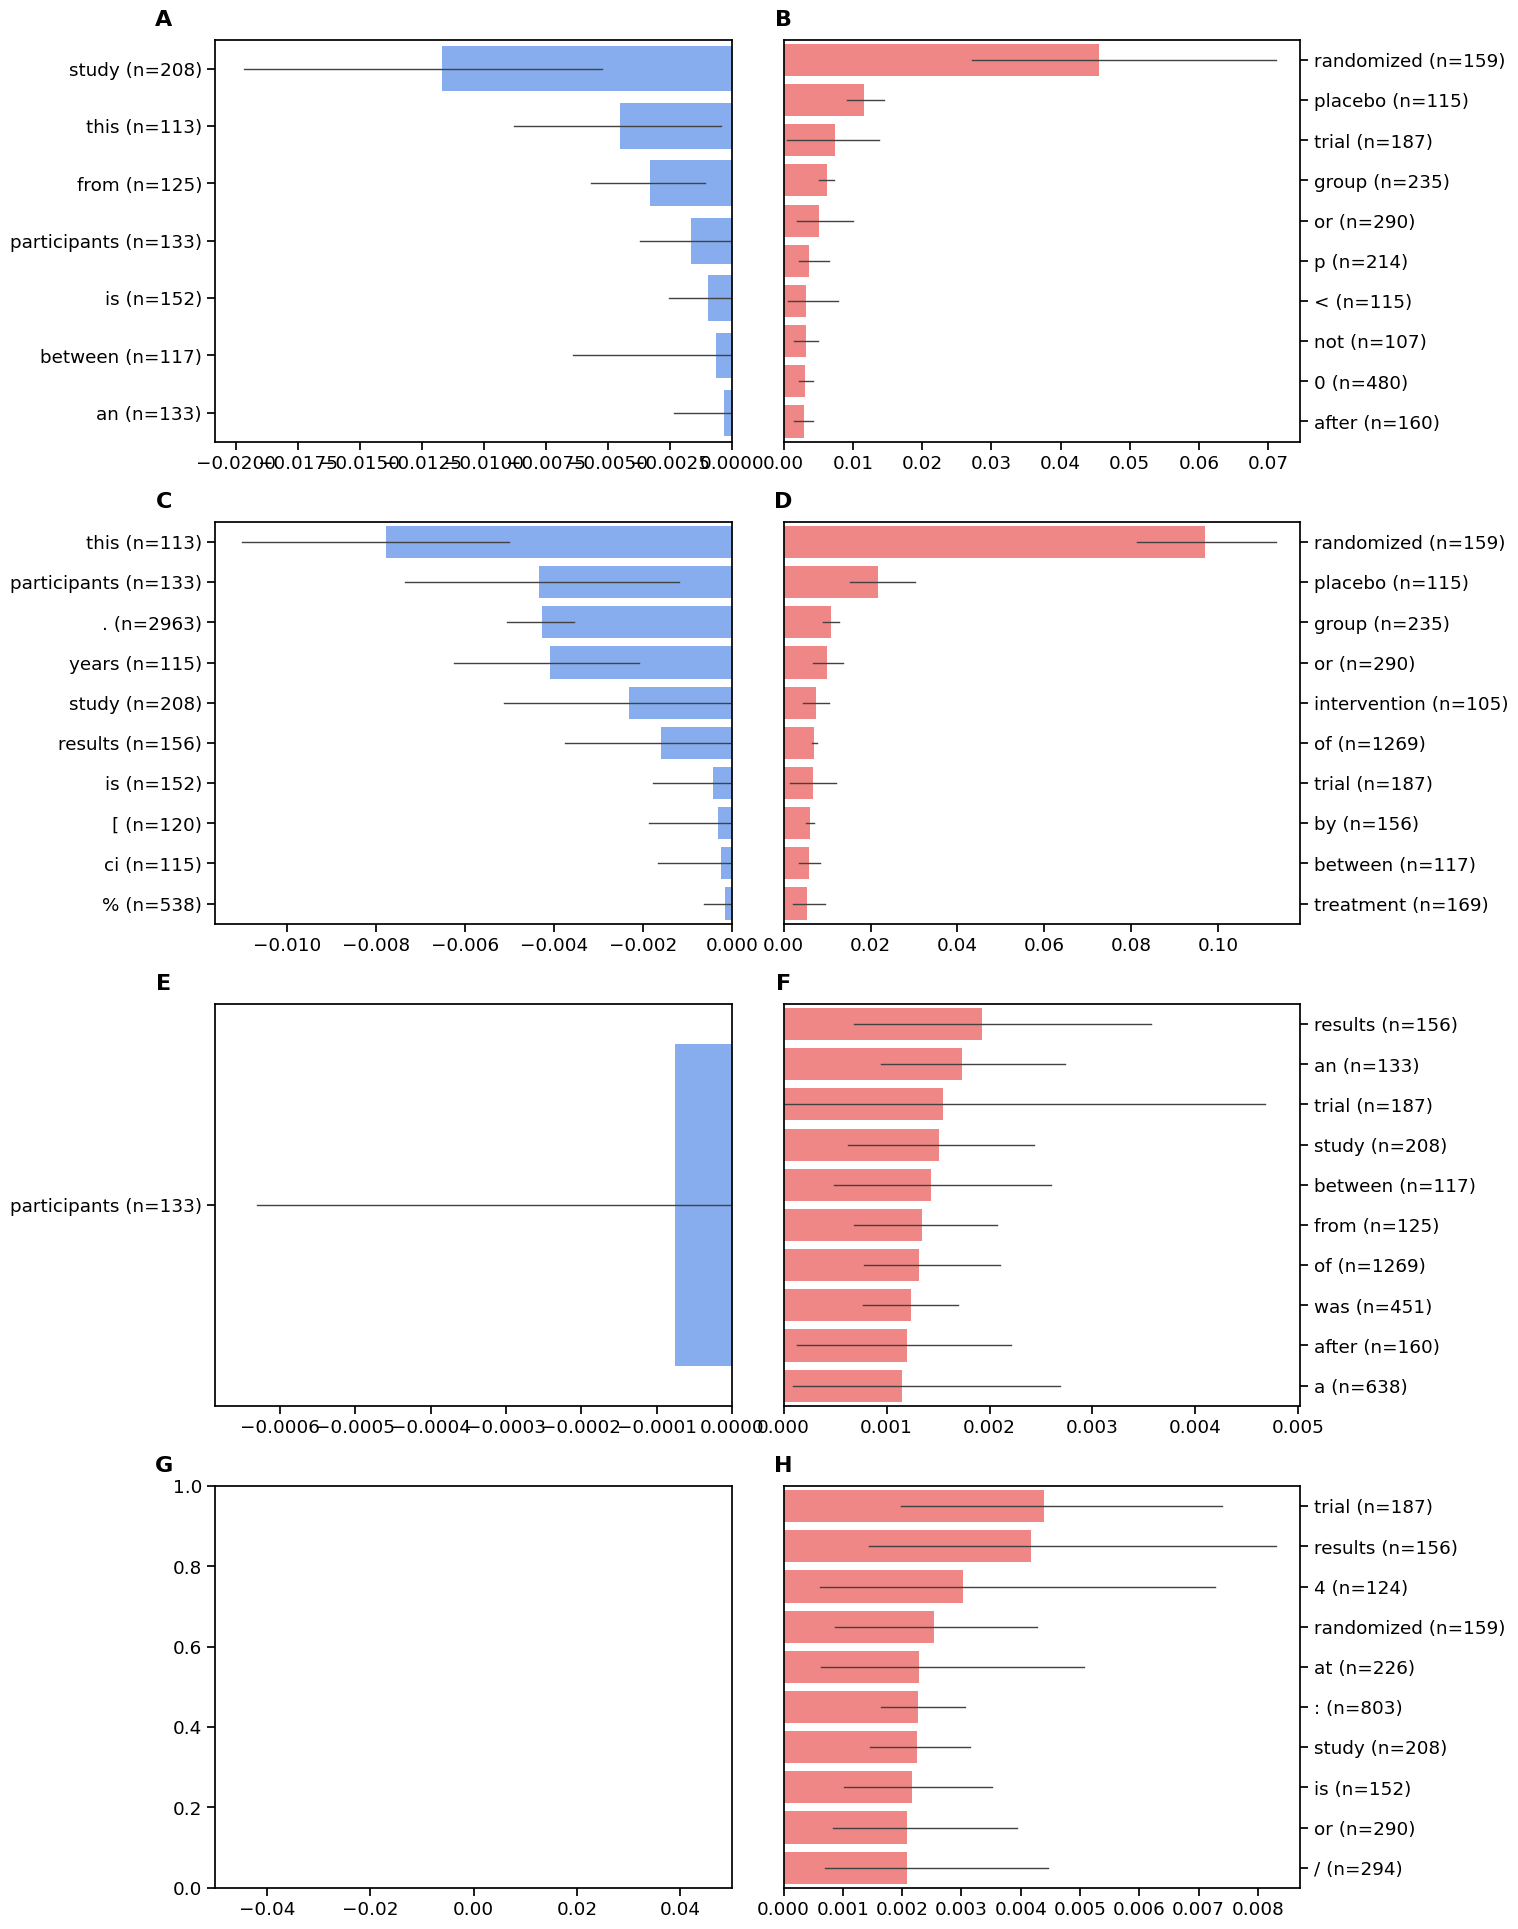

In [ ]:
explainer_result_cols = ['sv_value', 'ig_value', 'gpt_index_value', 'gpt_index_word_value']

tokens = df['ig_token']
token_counts = tokens.value_counts()

print(df["id"].nunique())
print(f"N features: {len(tokens)}")
print(f"N unique features: {len(tokens.unique())}")
print(df['ig_token'].isna().sum())

print(len(token_counts))

sns.set_context("notebook", font_scale=1.2)
for occurance in [1, 10, 100]:
    df_occurance = df[tokens.isin(token_counts[token_counts >= occurance].index)]
    print(f"There are {len(token_counts[token_counts >= occurance])} unique tokens that occurred {occurance}+ times.")
    print(f"{len(df_occurance)} tokens remain.")

    labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

    fig, axes = plt.subplots(4, 2, figsize=(14, 24), sharey=False, gridspec_kw={'wspace': 0.1})
    axes = axes.flatten()

    columns_and_features = [(col, ascending) for col in explainer_result_cols for ascending in [True, False]]

    for i, cf in enumerate(columns_and_features):
        col, ascending = cf
        df_occurance_unique_tokens = df_occurance.groupby('ig_token')[col]
        # print(occurance, col)

        # Create a single figure with two subplots
        # Create a figure with two side-by-side plots
        # fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False, gridspec_kw={'wspace': 0.1})  # Adjust spacing

        # labels = ['A', 'B']  # Labels for subplots
        positions = [(-0.1, 1.05), (0, 1.05)]  # Positions for labels (left for first, right for second)

        # Calculate median and absolute median for sorting
        unique_tokens_sorted = df_occurance_unique_tokens.mean().sort_values(ascending=ascending)

        # Keep only negative or positive features accordingly
        if ascending:
            unique_tokens_sorted = unique_tokens_sorted[unique_tokens_sorted < 0]  # Negative features
        else:
            unique_tokens_sorted = unique_tokens_sorted[unique_tokens_sorted > 0]  # Positive features

        # Select top 10 features
        top_unique_tokens = unique_tokens_sorted.head(NUM_TOP_FEATURES).index

        # Filter data for top 10 features
        df_occurance_top_tokens = df_occurance[df_occurance['ig_token'].isin(top_unique_tokens)]
        sample_sizes = df_occurance_top_tokens.groupby('ig_token')[col].count()

        # Create label with sample size
        df_occurance_top_tokens['tokens_with_sample_size'] = df_occurance_top_tokens['ig_token'].apply(
            lambda x: f"{x} (n={sample_sizes[x]})"
        )

        # Sort values for plotting
        df_occurance_unique_top_tokens = df_occurance_top_tokens.groupby('ig_token')[col]
        stats = df_occurance_unique_top_tokens.mean().sort_values(ascending=ascending)

        # Define colors
        colors = ['#ff7675' if val > 0 else '#76A9FF' for val in stats]
        order = [f"{tokens} (n={sample_sizes[tokens]})" for tokens in stats.index]

        # Plot
        sns.barplot(
            data=df_occurance_top_tokens,
            x=col,
            y='tokens_with_sample_size',
            palette=colors,
            orient='h',
            order=order,
            ax=axes[i],
            err_kws={'linewidth': 1}
        )

        # Formatting
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

        # Adjust x-axis limits
        if ascending:  # Negative values: Ensure x-axis ends at 0
            axes[i].set_xlim(None, 0)
            axes[i].yaxis.tick_left()
        else:  # Positive values: Ensure x-axis starts at 0
            axes[i].set_xlim(0, None)
            axes[i].yaxis.tick_right()

        # Add labels 'A' and 'B' at the top-left of each subplot
        axes[i].text(positions[i % 2][0], positions[i % 2][1], labels[i], transform=axes[i].transAxes,
                        fontsize=16, fontweight='bold', va='center', ha='center')

    # # Adjustments to move y-axis labels (feature names) to the right on the positive figure
    # axes[0].yaxis.tick_left()  # Keep y-axis labels on the left for negative features
    # axes[1].yaxis.tick_right()  # Move y-axis labels to the right for positive features

    # plt.tight_layout()
    # for format in ['png', 'svg']:
    #     save_path = r_path / "feature_importance_figures_large_text"
    #     save_path.mkdir(parents=True, exist_ok=True)
    #     plt.savefig(save_path / f"{occurance}.{format}", bbox_inches='tight')
    # plt.show()

# Regression

,dataset,SHAP,IG,GPT-index,GPT-token
0,train,-0.002235,-0.044053,0.0035,0.015
1,train,0.005878,-0.003780,0.0028,0.005
2,train,-0.000972,-0.004581,0.0023,0.008
3,train,-0.000972,0.002719,0.0031,0.002
4,train,-0.000972,0.010749,0.0027,0.012


Pearson correlation between sv_value and ig_value: 0.358, P-value: 0.000
Spearman correlation between sv_value and ig_value: 0.293, P-value: 0.000
Kendall's Tau between sv_value and ig_value: 0.205, P-value: 0.000
Wasserstein Distance between sv_value and ig_value: 0.002
Pearson correlation between sv_value and gpt_index_value: -0.048, P-value: 0.000
Spearman correlation between sv_value and gpt_index_value: 0.077, P-value: 0.000
Kendall's Tau between sv_value and gpt_index_value: 0.050, P-value: 0.000
Wasserstein Distance between sv_value and gpt_index_value: 0.005
Pearson correlation between sv_value and gpt_index_word_value: 0.003, P-value: 0.524
Spearman correlation between sv_value and gpt_index_word_value: 0.041, P-value: 0.000
Kendall's Tau between sv_value and gpt_index_word_value: 0.027, P-value: 0.000
Wasserstein Distance between sv_value and gpt_index_word_value: 0.004
Pearson correlation between ig_value and gpt_index_value: 0.011, P-value: 0.007
Spearman correlation betwee

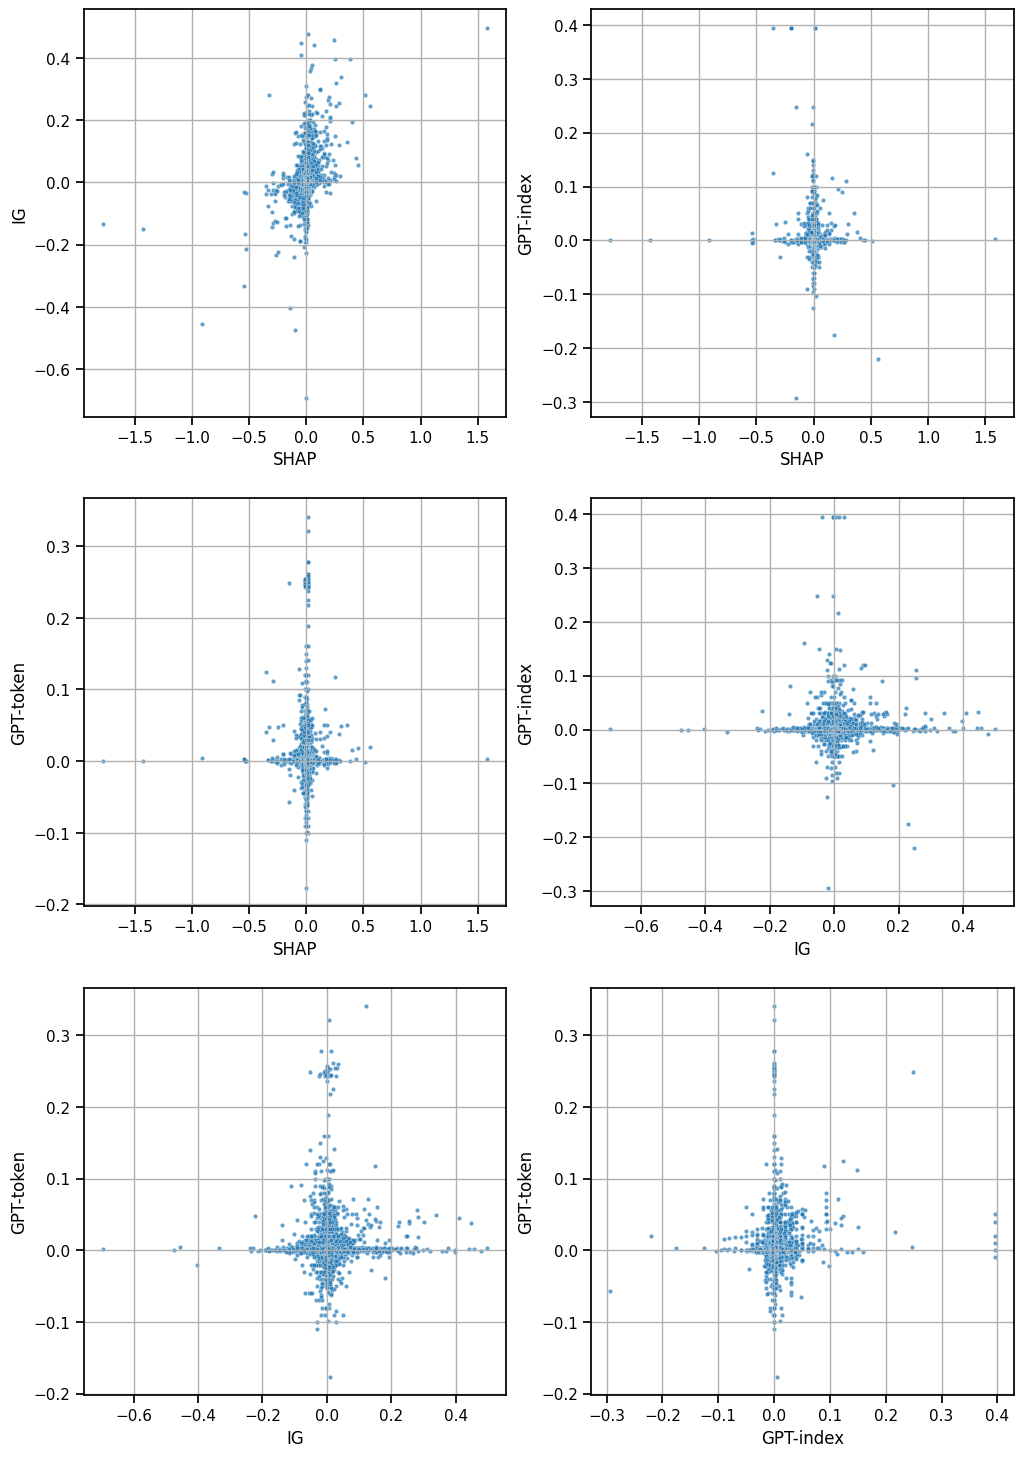

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr, pearsonr, wasserstein_distance
from sklearn.linear_model import LinearRegression
import itertools
import seaborn as sns
import os

# df = pd.read_csv(os.path.join('results', 'stratified_results.csv'))


def analyze(a, b):
    x = df[a]
    y = df[b]

    # Calculate Pearson correlation
    correlation, p_value = pearsonr(x, y)
    print(f"Pearson correlation between {a} and {b}: {correlation:.3f}, P-value: {p_value:.3f}")

    # Calculate Spearman correlation
    correlation, p_value = spearmanr(x, y)
    print(f"Spearman correlation between {a} and {b}: {correlation:.3f}, P-value: {p_value:.3f}")

    # Calculate Kendall's Tau
    tau, p_value = kendalltau(x, y)
    print(f"Kendall's Tau between {a} and {b}: {tau:.3f}, P-value: {p_value:.3f}")

    # Calculate Wasserstein distance
    distance = wasserstein_distance(x, y)
    print(f"Wasserstein Distance between {a} and {b}: {distance:.3f}")

sns.set_context("notebook", font_scale=1)

cols_mapping = {
    'sv_value': "SHAP", 
    'ig_value': "IG",
    'gpt_index_value': "GPT-index",
    'gpt_index_word_value': "GPT-token",
}

pairs = list(itertools.combinations(cols_mapping.keys(), 2))

with open("info.json", "r") as f:
    info = json.load(f)

df_plot = df[['dataset', 'sv_value', 'ig_value', 'gpt_index_value', 'gpt_index_word_value']]
df_plot.rename(columns=cols_mapping, inplace=True)
display(df_plot.head())

# sns.pairplot(df_plot, hue='dataset')

fig, axes = plt.subplots(3, 2, figsize=(12, 18), sharey=False, gridspec_kw={'wspace': 0.2},)
axes = axes.flatten()
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']

for i, pair in enumerate(pairs):
    a, b = pair
    df[a].fillna(0, inplace=True)
    df[b].fillna(0, inplace=True)

    analyze(a, b)
    
    # Scatter plot
    sns.scatterplot(x=df[a], y=df[b], s=10, alpha=0.7, ax=axes[i])

    axes[i].set_xlabel(cols_mapping[a])
    axes[i].set_ylabel(cols_mapping[b])
    axes[i].grid(True)
    # axes[i].text(-0.1, 1.05, labels[i], transform=axes[i].transAxes,
    #              fontsize=12, fontweight='bold', va='center', ha='center')
# for format in ['pdf', 'tif', 'svg']:
#     plt.savefig(r_path / "feature_importance_figures" / f"regression.{format}", bbox_inches='tight')
# plt.savefig(os.path.join("feature_importance_figures", f"regression.svg"), bbox_inches='tight')
plt.show()

# Area over the perturbation curve

## Process AOPCs

In [ ]:

from tqdm import tqdm
import json
import pandas as pd

import scipy.stats as stats
import numpy as np

cols_mapping = {
    'sv_value': "SHAP",
    'ig_value': "IG",
    'gpt_index_value': "GPT-index",
    'gpt_index_word_value': "GPT-token",
}

df_aopc = pd.read_csv(os.path.join('results', "200_aopc.csv"))
df_aopc = df_aopc[df_aopc['id'].isin(correct_ids)]
print(df_aopc["id"].nunique())
def mean_ci(series, confidence=0.95):
    series = series.dropna()  # Remove NaN values
    if len(series) == 0:  # If empty after dropping NaNs, return "NaN"
        return "NaN (NaN, NaN)"

    mean = np.mean(series)

    if len(series) == 1:  # If only one value, no confidence interval can be calculated
        return f"{mean:.3f}"

    sem = stats.sem(series)  # Standard error of the mean
    ci_range = sem * stats.t.ppf((1 + confidence) / 2., len(series) - 1)
    lower = mean - ci_range
    upper = mean + ci_range

    return f"{mean:.3f} ({lower:.3f}, {upper:.3f})"


output = []

for explainer in cols_mapping.keys():
    output.append({
        "Explainer": cols_mapping[explainer],
        "AOPC": mean_ci(df_aopc[f'aopc_{explainer}']),
        "AOPC (Positive Tokens)": mean_ci(df_aopc[f'aopc_pos_{explainer}']),
        "AOPC (Negative Tokens)": mean_ci(df_aopc[f'aopc_neg_{explainer}']),
    })

    
df_output = pd.DataFrame(output)
r_path.mkdir(parents=True, exist_ok=True)
df_output.to_csv(r_path / "aopc_results_correct_only.csv", index=False)
display(df_output)

141


,Explainer,AOPC,AOPC (Positive Tokens),AOPC (Negative Tokens)
0,SHAP,"0.212 (0.184, 0.240)","0.255 (0.219, 0.291)","0.039 (0.031, 0.047)"
1,IG,"0.214 (0.185, 0.243)","0.303 (0.260, 0.346)","0.024 (0.016, 0.032)"
2,GPT-index,"0.033 (0.017, 0.049)","0.046 (0.025, 0.068)","-0.010 (-0.022, 0.003)"
3,GPT-token,"0.024 (0.007, 0.042)","0.041 (0.017, 0.066)","-0.015 (-0.028, -0.003)"


#### AOPC Curves

282
282
282
282
141
141
141
141
141
141
141
141


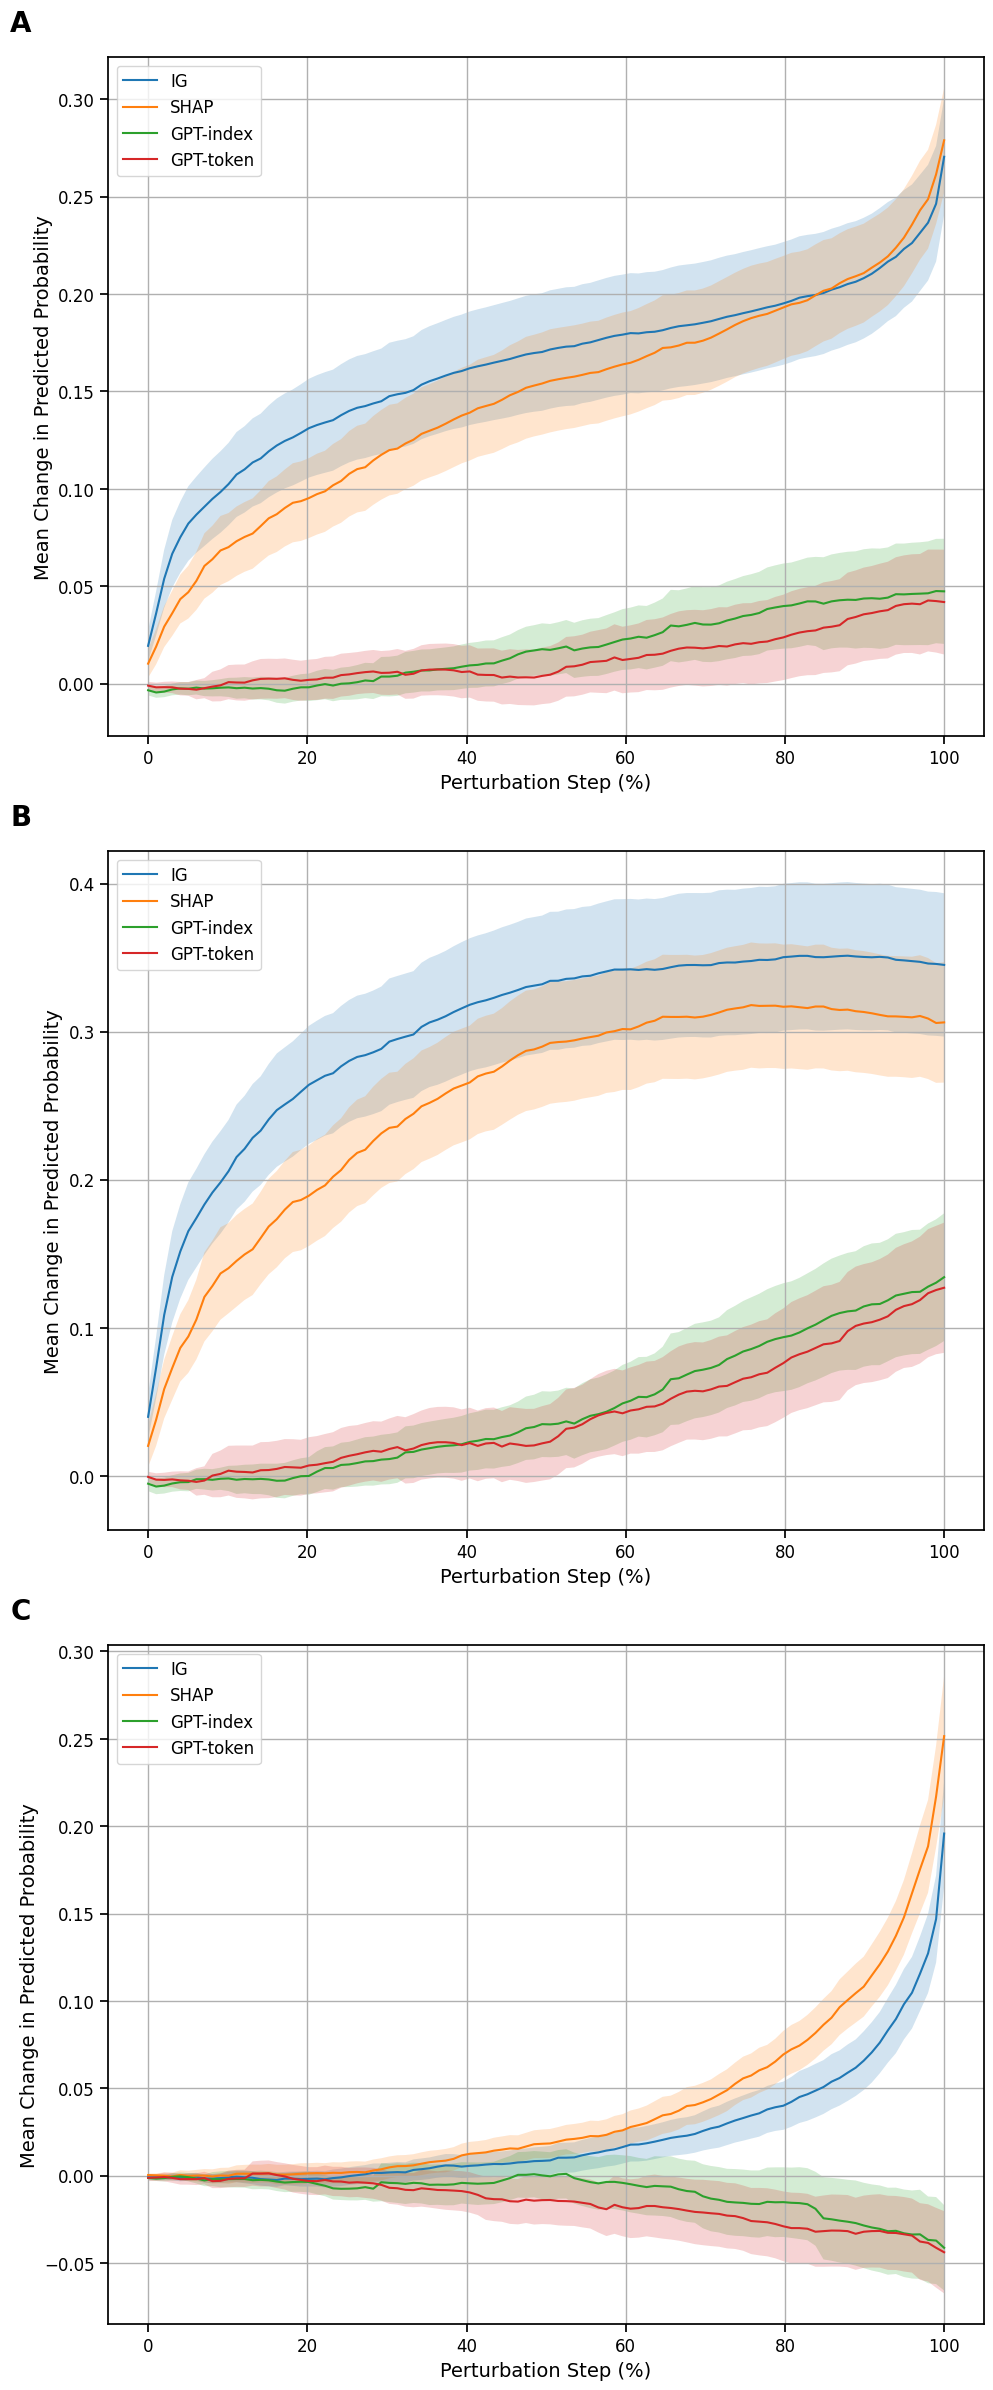

In [ ]:
from tqdm import tqdm
import json
import pandas as pd

from scipy.stats import norm
import numpy as np
import workers
import matplotlib.pyplot as plt
from pathlib import Path

spacing = np.linspace(0, 1, 100)
# df = pd.read_csv(os.path.join('results', 'stratified_results.csv'))
file_path = Path("results") / "200_pc_per_token"

def get_aopc_curve_values(file: str):
    spacing = np.linspace(0, 1, 100)

    df_aopc = pd.read_csv(file)
    df_aopc['step_percent'] = (df_aopc['index'] + 1) / len(df_aopc)

    try:
        interpolated = np.interp(spacing, df_aopc['step_percent'], df_aopc['pc_value'])
    except Exception as e:
        return None, file
    return interpolated, file

# dfs_by_id = {key: value for key, value in df_results.groupby("id")}
# cols = ["ig_value", "sv_value", "gpt_index_value", "gpt_index_word_value"]
cols = {
    "ig_value": "IG",
    "sv_value": "SHAP",
    "gpt_index_value": "GPT-index",
    "gpt_index_word_value": "GPT-token",
}
# df = df[cols]

fig, axes = plt.subplots(3, 1, figsize=(10, 24))
for i, sign in enumerate(["all", "pos", "neg"]): # need 3 figures

    for col in cols:
        # need one curve per col in each figure
        files = (
            list(file_path.glob(f"*{col}_{sign}.csv"))
            if sign != "all"
            else list(file_path.glob(f"*{col}*.csv"))
        )
        dfs = []
        for file in files:
            file_name = file.name
            # print(len(correct_ids))
            # print(file_name.split("_")[0])
            if file_name.split("_")[0] not in correct_ids.values.astype(str): # only include curves for correctly predicted instances
                continue
            dfs.append(pd.read_csv(file))
        
        # print(files)
        # dfs = [pd.read_csv(file) for file in files]

        apocs = []

        for d in dfs:
            if len(d) == 0:
                continue
            d['step_percent'] = (np.arange(len(d)) + 1) / len(d)
            interpolated = np.interp(spacing, d['step_percent'].astype(float), d['pc_value'].astype(float))
            apocs.append(interpolated)
        # print(dfs_interpolated)
        # print(df_interpolated.head())
        # print(curve)
        mean_curve = np.array(apocs).mean(axis=0)
        std_curve = np.array(apocs).std(axis=0)
        n = len(apocs)
        z = norm.ppf(0.975)  # 95% CI
        ci_margin = z * std_curve / np.sqrt(n)

        axes[i].plot(spacing*100, mean_curve, label=f'{cols[col]}')
        axes[i].fill_between(spacing*100, mean_curve - ci_margin, mean_curve + ci_margin, alpha=0.2)

    axes[i].set_xlabel('Perturbation Step (%)', fontsize=14)
    axes[i].set_ylabel('Mean Change in Predicted Probability', fontsize=14)
    axes[i].tick_params(axis='both', which='major', labelsize=12)
    axes[i].legend(fontsize=12)
    axes[i].grid(True)
    axes[i].text(-0.1, 1.05, ['A', 'B', 'C'][i], transform=axes[i].transAxes,
                 fontsize=20, fontweight='bold', va='center', ha='center')
plt.tight_layout()
# plt.savefig("200_apoc_curves.svg", bbox_inches='tight')
# plt.savefig("200_apoc_curves.tiff", dpi=300, bbox_inches='tight')
# plt.savefig("200_apoc_curves.png", dpi=300, bbox_inches="tight")
# plt.savefig("200_apoc_curves.pdf", bbox_inches="tight")
plt.show()